# **Time-Series Analysis and Forecasting Individual Project**

 Department: Industrial Engineering

 Student ID: **2022093854**

 Name: **Huh Jeonghu**

In [4]:
# import tools for analyzing timeseries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pandas.tseries.offsets import DateOffset
import itertools

In [5]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/AirPassengers.csv',names=['month','passengers'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
data['month'] = pd.to_datetime(data['month'], format='%Y-%m')
data.set_index('month', inplace=True)


# Data 1949 ~ 1959 : training set / Data 1959 ~ 1960 : testing set
train_data = data[:'1958']
test_data = data['1959':]

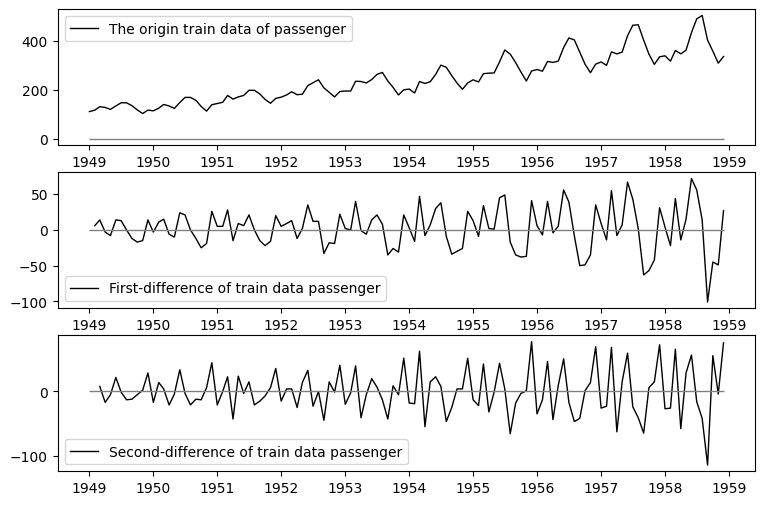

In [7]:
f, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 2*3))

axes[0].plot(train_data['passengers'],color='black',linewidth=1,label='The origin train data of passenger')
axes[0].hlines(xmin=train_data.index[0],xmax=train_data.index[-1],y=0,color='gray',linewidth=1)
axes[0].legend()

axes[1].plot(train_data['passengers'].diff(),color='black',linewidth=1,label='First-difference of train data passenger')
axes[1].hlines(xmin=train_data.index[0],xmax=train_data.index[-1],y=0,color='gray',linewidth=1)
axes[1].legend()

axes[2].plot(train_data['passengers'].diff().diff(),color='black',linewidth=1, label='Second-difference of train data passenger')
axes[2].hlines(xmin=train_data.index[0],xmax=train_data.index[-1],y=0,color='gray',linewidth=1)
axes[2].legend()
plt.show()

In [8]:
def adf_test(dataframe):
  result = adfuller(dataframe)
  print(f'Statistics: {result[0]}')
  print(f'p-value: {result[1]}')
  print(f'Critical values: {result[4]}')

adf_test(train_data['passengers'])
print('---'*40)
adf_test(train_data['passengers'].diff().dropna())
print('---'*40)
adf_test(train_data['passengers'].diff().diff().dropna())

Statistics: -0.773460770896928
p-value: 0.8267937485032476
Critical values: {'1%': -3.4936021509366793, '5%': -2.8892174239808703, '10%': -2.58153320754717}
------------------------------------------------------------------------------------------------------------------------
Statistics: -2.1641431278047816
p-value: 0.2195157763715047
Critical values: {'1%': -3.4936021509366793, '5%': -2.8892174239808703, '10%': -2.58153320754717}
------------------------------------------------------------------------------------------------------------------------
Statistics: -13.94736364206576
p-value: 4.770419684030554e-26
Critical values: {'1%': -3.4936021509366793, '5%': -2.8892174239808703, '10%': -2.58153320754717}


(1) Origin data can't reject the null hypothesis because the statistic > given Critical value & the p-value > 0.05

==> the data can be interpreted as Nonstationarity.

(2) First-difference data can't reject the null hypothesis because the statistic > given Critical value & the p-value > 0.05

==> the data can be interpreted as Nonstationarity.

(3) Second-differerne data reject the null hypothesis because the statistic < given Critical value & the p-value < 0.05

==> the data can be considered Stationarity.

In [9]:
def kpss_test(dataframe):
  result = kpss(dataframe)
  print(f'Statistics: {result[0]}')
  print(f'bounded p-value: {result[1]}')
  print(f'Critical values: {result[3]}')

kpss_test(train_data['passengers'])
print('---'*40)
kpss_test(train_data['passengers'].diff().dropna())
print('---'*40)
kpss_test(train_data['passengers'].diff().diff().dropna())

Statistics: 1.7058124992217791
bounded p-value: 0.01
Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
------------------------------------------------------------------------------------------------------------------------
Statistics: 0.019023125650029386
bounded p-value: 0.1
Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
------------------------------------------------------------------------------------------------------------------------
Statistics: 0.08275298336937394
bounded p-value: 0.1
Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


<ipython-input-9-d16057762667>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(dataframe)
<ipython-input-9-d16057762667>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(dataframe)
<ipython-input-9-d16057762667>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(dataframe)


(1) Origin data can't reject the null hypothesis because the statistic > given Critical value & the p-value > 0.05

==> the data can be interpreted as Nonstationarity.

(2) First-difference data reject the null hypothesis because the statistic < given Critical value & the p-value < 0.05

==> the data can be be considered Stationarity.

(3) Second-differerne data reject the null hypothesis because the statistic < given Critical value & the p-value < 0.05

==> the data can be considered Stationarity.

* Summary

In ADF test : only Second-difference data can be considered Statinarity.
So it can only use second-difference data to forecast the future.

In KPSS test : both First-difference data and Second-difference data can be considered Stationarity.

# **ACF / PACF of Non-differential data**


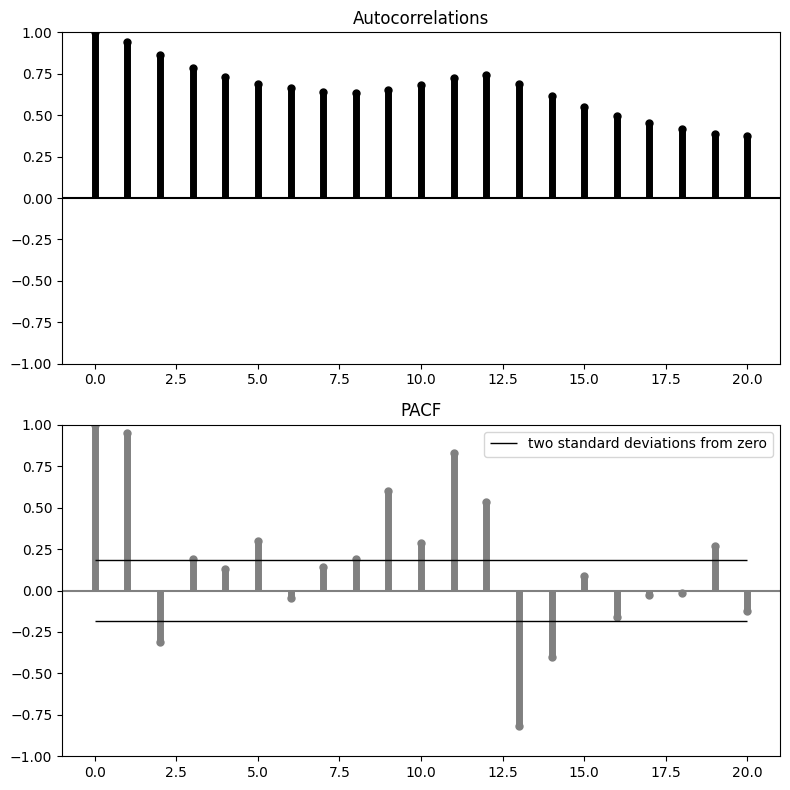

In [10]:
f, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 2*4))
plot_acf(train_data['passengers'], lags=20, ax=axes[0], title='Autocorrelations', color='black',vlines_kwargs={'colors':'black','linewidth':5}, alpha=None)
plot_pacf(train_data['passengers'], lags=20, ax=axes[1], method='ols', title='PACF', color='gray',vlines_kwargs={'colors':'gray','linewidth':5}, alpha=None)
axes[1].hlines(xmin=0,xmax=20,y=2*np.sqrt(1/len(train_data['passengers'])),label='two standard deviations from zero',color='black',linewidth=1)
axes[1].hlines(xmin=0,xmax=20,y=-2*np.sqrt(1/len(train_data['passengers'])),color='black',linewidth=1)
axes[1].legend()
plt.tight_layout()
plt.show()

The ACF does not converge to zero, so we need to over-difference the spread series to have a stationary mean.

# **ACF / PACF of First-differential data**


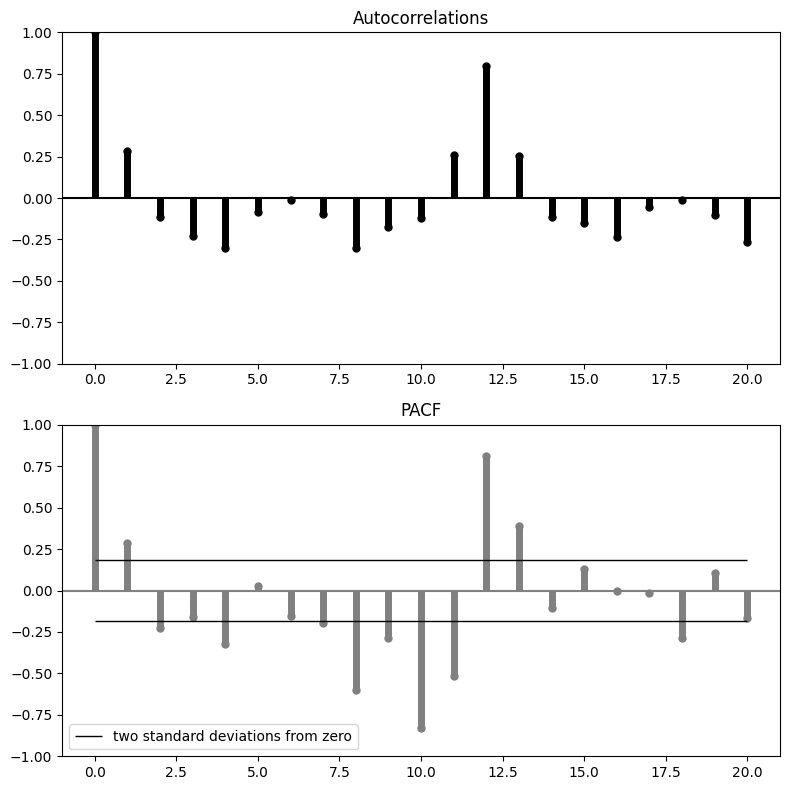

In [11]:
f, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 2*4))
plot_acf(train_data['passengers'].diff().dropna(), lags=20, ax=axes[0], title='Autocorrelations', color='black',vlines_kwargs={'colors':'black','linewidth':5}, alpha=None)
plot_pacf(train_data['passengers'].diff().dropna(), lags=20, ax=axes[1], method='ols', title='PACF', color='gray',vlines_kwargs={'colors':'gray','linewidth':5}, alpha=None)
axes[1].hlines(xmin=0,xmax=20,y=2*np.sqrt(1/len(train_data['passengers'].diff().dropna())),label='two standard deviations from zero',color='black',linewidth=1)
axes[1].hlines(xmin=0,xmax=20,y=-2*np.sqrt(1/len(train_data['passengers'].diff().dropna())),color='black',linewidth=1)
axes[1].legend()
plt.tight_layout()
plt.show()

# **ACF / PACF of Second-differential data**


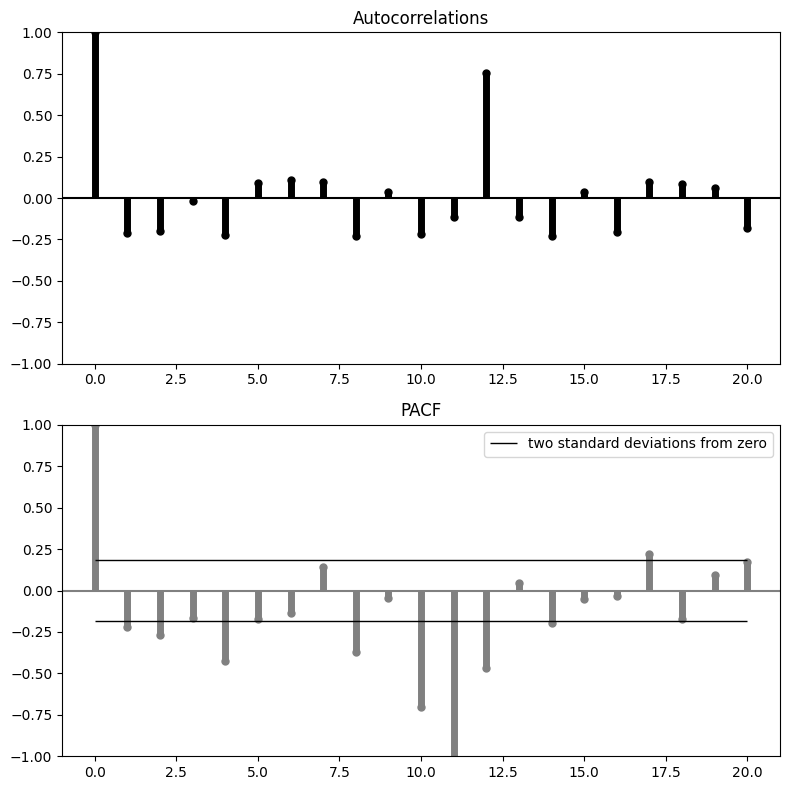

In [12]:
f, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 2*4))
plot_acf(train_data['passengers'].diff().diff().dropna(), lags=20, ax=axes[0], title='Autocorrelations', color='black',vlines_kwargs={'colors':'black','linewidth':5}, alpha=None)
plot_pacf(train_data['passengers'].diff().diff().dropna(), lags=20, ax=axes[1], method='ols', title='PACF', color='gray',vlines_kwargs={'colors':'gray','linewidth':5}, alpha=None)
axes[1].hlines(xmin=0,xmax=20,y=2*np.sqrt(1/len(train_data['passengers'].diff().dropna())),label='two standard deviations from zero',color='black',linewidth=1)
axes[1].hlines(xmin=0,xmax=20,y=-2*np.sqrt(1/len(train_data['passengers'].diff().dropna())),color='black',linewidth=1)
axes[1].legend()
plt.tight_layout()
plt.show()

In Second-difference data, both ACF and PACF converge to zero quickly enough. So they can be said to be Sationary.
In ACF, it can be considered appropriate q as 12 because it peakes at lag 12. In PACF, we can select p as 10 & 11 & 12 bacause they show increasing and decreasing sharply at lag 10 to 12.
As a result, I will consider the graph (10,2,12) & (11,2,12) & (12,2,12).

Actually, determining p and q based on ACF and PACF has some limitation because they do not provide clear-cut for p and q. However, they can provide insights into the correlation pattern in data so that we can challenge to determine the orders of AR(i.e. p) and MA(i.e. q) components.

To overcome the limitations of selecting appropriate p(for AR) and q(for MA) based on ACF and PACF, we have to do additional techniques such as diagonostic check for models and model selection criteria(such as AIC and SBC) etc.

# **Finding p and q (by using Grid Search)**

Now, to find the coefficients of models(ie.e parameter values) that can makes the best model performance, i will search all values (Grid Search). And then determine the parameters that can make smallest AIC/SBC values.

In [13]:
import warnings
warnings.filterwarnings("ignore")

aic_,sbc_,para=[],[],[]
#fit ARIMA model and append the results
for p in range(0,15):
  for q in range(0,3):
    try:
      m=ARIMA(train_data['passengers'].dropna(), order=(p,2,q)).fit()

      aic_.append(m.aic)
      sbc_.append(m.bic)
      para.append((p,q))

    except:
      continue


In [14]:
#find best parameter of AIC & SBC

best_aic_idx=np.argsort(aic_)[:3]
best_sbc_idx=np.argsort(sbc_)[:3] #get index of best parameters

print("Best Parameters for AIC")
for i in best_aic_idx:
  p_best,q_best=para[i]
  print(" p =",p_best,", q =",q_best, ", AIC:",aic_[i])

print("\nBest Parameters for SBC")
for i in best_sbc_idx:
  p_best,q_best=para[i]
  print(" p =",p_best,", q =",q_best, ", AIC:",sbc_[i])

Best Parameters for AIC
 p = 12 , q = 0 , AIC: 926.1404712185604
 p = 13 , q = 1 , AIC: 926.1529422852358
 p = 14 , q = 1 , AIC: 926.7504631349528

Best Parameters for SBC
 p = 12 , q = 0 , AIC: 962.1593713366141
 p = 11 , q = 0 , AIC: 964.1640002882197
 p = 11 , q = 2 , AIC: 965.9730517145027


Best models using AIC: ARIMA(11,2,1) & ARIMA(12,2,0) & ARIMA(13,2,1)

Best models using BIC : ARIMA(11,2,1) & ARIMA(12,2,0) & ARIMA(11,2,0)

   
Thus, I will test the performance of 4 models : ARIMA(11,2,0) & ARIMA(11,2,1) & ARIMA(12,2,0) & ARIMA(13,2,1)

# ARIMA(11,2,0)

In [15]:
model1 = ARIMA(data['passengers'], order=(11, 2, 0)).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             passengers   No. Observations:                  144
Model:                ARIMA(11, 2, 0)   Log Likelihood                -565.103
Date:                Thu, 06 Jun 2024   AIC                           1154.207
Time:                        15:25:50   BIC                           1189.677
Sample:                    01-01-1949   HQIC                          1168.620
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9464      0.047    -20.103      0.000      -1.039      -0.854
ar.L2         -0.9665      0.038    -25.640      0.000      -1.040      -0.893
ar.L3         -0.9567      0.057    -16.728      0.000      -1.069      -0.845
ar.L4         -0.9668      0.045    -21.418      0.000      -1.055      -0.878
ar.L5         -0.9292      0.060    -15.497      0.000      -1.047      -0.812
ar.L6         -0.9450      0.039    -24.350      0.000      -1.021      -0.869
ar.L7         -0.9256      0.054    -17.248      0.000      -1.031      -0.820
ar.L8         -0.9907      0.041    -23.968      0.000      -1.072      -0.910
ar.L9         -0.9213      0.045    -20.695      0.000      -1.009      -0.834
ar.L10        -0.9729      0.034    -28.614      0.000      -1.040      -0.906
ar.L11        -0.8935      0.045    -19.905      0.000      -0.981      -0.806
sigma2       145.6875     17.572      8.291      0.000     111.248     180.127
===================================================================================
Ljung-Box (L1) (Q):                  12.53   Jarque-Bera (JB):                25.80
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.35   Skew:                             0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

NOTE 1) Ljung–Box Q-statistics can serve as a check to see if the residuals from an estimated ARMA(p, q) model behave as a white-noise process.

NOTE2) In the absence of autocorrelation, the prob(Q) value is close to 1

IN ARIMA(11,2,0), the Q value is 12.53 which is very high value so it can be explained there is strong autocorrelation between residuals.
And also, Prob(Q) value is 0.00 which means there is very strong autocorrelation.

# ARIMA(11,2,1)

In [16]:
model2 = ARIMA(data['passengers'], order=(11, 2, 1)).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             passengers   No. Observations:                  144
Model:                ARIMA(11, 2, 1)   Log Likelihood                -557.649
Date:                Thu, 06 Jun 2024   AIC                           1141.297
Time:                        15:25:52   BIC                           1179.723
Sample:                    01-01-1949   HQIC                          1156.912
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8713      0.069    -12.641      0.000      -1.006      -0.736
ar.L2         -0.9382      0.044    -21.302      0.000      -1.025      -0.852
ar.L3         -0.9004      0.070    -12.876      0.000      -1.037      -0.763
ar.L4         -0.9436      0.042    -22.702      0.000      -1.025      -0.862
ar.L5         -0.8743      0.067    -12.985      0.000      -1.006      -0.742
ar.L6         -0.9188      0.031    -29.660      0.000      -0.980      -0.858
ar.L7         -0.8730      0.067    -13.017      0.000      -1.004      -0.742
ar.L8         -0.9720      0.044    -22.250      0.000      -1.058      -0.886
ar.L9         -0.8701      0.054    -16.249      0.000      -0.975      -0.765
ar.L10        -0.9471      0.040    -23.802      0.000      -1.025      -0.869
ar.L11        -0.8493      0.064    -13.348      0.000      -0.974      -0.725
ma.L1         -0.3844      0.101     -3.819      0.000      -0.582      -0.187
sigma2       139.1191     19.775      7.035      0.000     100.360     177.878
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 5.48
Prob(Q):                              0.87   Prob(JB):                         0.06
Heteroskedasticity (H):               3.55   Skew:                             0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

IN ARIMA(11,2,1), the Q value is 0.03 which is very low value so it can be explained there is no autocorrelation between residuals.
And also, Prob(Q) value is 0.87 which means there is no  autocorrelation.

# ARMIA(12,2,0)

In [17]:
model3 = ARIMA(data['passengers'], order=(12, 2, 0)).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             passengers   No. Observations:                  144
Model:                ARIMA(12, 2, 0)   Log Likelihood                -557.968
Date:                Thu, 06 Jun 2024   AIC                           1141.937
Time:                        15:25:55   BIC                           1180.363
Sample:                    01-01-1949   HQIC                          1157.551
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2633      0.092    -13.686      0.000      -1.444      -1.082
ar.L2         -1.3339      0.093    -14.352      0.000      -1.516      -1.152
ar.L3         -1.2771      0.096    -13.253      0.000      -1.466      -1.088
ar.L4         -1.3540      0.096    -14.156      0.000      -1.541      -1.167
ar.L5         -1.2468      0.102    -12.252      0.000      -1.446      -1.047
ar.L6         -1.3197      0.092    -14.308      0.000      -1.500      -1.139
ar.L7         -1.2444      0.089    -13.904      0.000      -1.420      -1.069
ar.L8         -1.3674      0.086    -15.810      0.000      -1.537      -1.198
ar.L9         -1.2654      0.093    -13.626      0.000      -1.447      -1.083
ar.L10        -1.3426      0.091    -14.816      0.000      -1.520      -1.165
ar.L11        -1.2164      0.100    -12.129      0.000      -1.413      -1.020
ar.L12        -0.3934      0.090     -4.354      0.000      -0.571      -0.216
sigma2       145.5089     21.070      6.906      0.000     104.213     186.805
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.38
Prob(Q):                              0.98   Prob(JB):                         0.11
Heteroskedasticity (H):               3.54   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

IN ARIMA(12,2,0), the Q value is 0.00, so it can be explained there is no autocorrelation between residuals.
And also, Prob(Q) value is 0.98 (very close to 1), so it means there is no autocorrelation.

# ARIMA(13,2,1)

In [18]:
model4 = ARIMA(data['passengers'], order=(13, 2, 1)).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             passengers   No. Observations:                  144
Model:                ARIMA(13, 2, 1)   Log Likelihood                -554.419
Date:                Thu, 06 Jun 2024   AIC                           1138.839
Time:                        15:25:58   BIC                           1183.176
Sample:                    01-01-1949   HQIC                          1156.856
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3203      0.123     -2.610      0.009      -0.561      -0.080
ar.L2         -0.2349      0.114     -2.067      0.039      -0.458      -0.012
ar.L3         -0.1541      0.139     -1.111      0.266      -0.426       0.118
ar.L4         -0.2036      0.126     -1.619      0.105      -0.450       0.043
ar.L5         -0.1345      0.130     -1.034      0.301      -0.389       0.121
ar.L6         -0.1960      0.127     -1.541      0.123      -0.445       0.053
ar.L7         -0.1530      0.128     -1.199      0.230      -0.403       0.097
ar.L8         -0.2541      0.138     -1.842      0.065      -0.524       0.016
ar.L9         -0.1000      0.134     -0.744      0.457      -0.364       0.164
ar.L10        -0.2438      0.123     -1.984      0.047      -0.485      -0.003
ar.L11        -0.1051      0.137     -0.769      0.442      -0.373       0.163
ar.L12         0.6994      0.119      5.897      0.000       0.467       0.932
ar.L13         0.2289      0.103      2.222      0.026       0.027       0.431
ma.L1         -0.9731      0.058    -16.837      0.000      -1.086      -0.860
sigma2       123.4375     17.069      7.232      0.000      89.983     156.892
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 9.24
Prob(Q):                              0.86   Prob(JB):                         0.01
Heteroskedasticity (H):               3.55   Skew:                            -0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

IN ARIMA(13,2,1), the Q value is 0.03 which is very low value so it can be explained there is no autocorrelation between residuals.
And also, Prob(Q) value is 0.87 which means there is no  autocorrelation.

# Summary of 4 ARIMA models

Among the four models above, three models( ARIMA(11,2,1)&(12,2,0)&(13,2,1) except (11,2,0) ) show that the residuals do not have autocorrelations through the Ljung-Box Q value and Prob(Q) results.

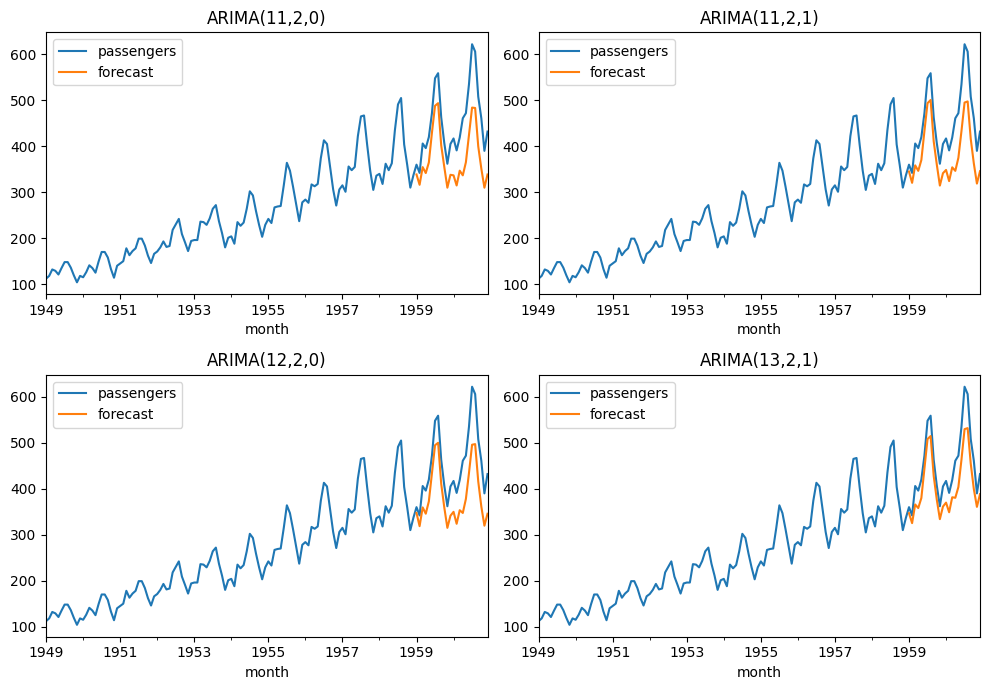

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=2,figsize = (10,7))

data['forecast'] = model1.predict(start = 12*10, end = 12*12-1, dynamic = True)
data[['passengers','forecast']].plot(title='ARIMA(11,2,0)',ax=axes[0][0])

data['forecast'] = model2.predict(start = 12*10, end = 12*12-1, dynamic = True)
data[['passengers','forecast']].plot(title='ARIMA(11,2,1)',ax=axes[0][1])

data['forecast'] = model3.predict(start = 12*10, end = 12*12-1, dynamic = True)
data[['passengers','forecast']].plot(title='ARIMA(12,2,0)',ax=axes[1][0])

data['forecast'] = model4.predict(start = 12*10, end = 12*12-1, dynamic = True)
data[['passengers','forecast']].plot(title='ARIMA(13,2,1)',ax=axes[1][1])
plt.tight_layout()

In [20]:
col=["","AIC","SBC"]
r1=["ARIMA(11,2,0)","1154.207","1189.677"]
r2=["ARIMA(11,2,1)","1141.297","1179.723"]
r3=["ARIMA(12,2,0)","1141.937","1180.363"]
r4=["ARIMA(13,2,1)","1138.839","1183.176"]

df=pd.DataFrame([r1,r2,r3,r4],columns=col)
df.set_index("",inplace=True)
df

,AIC,SBC
,,
"ARIMA(11,2,0)",1154.207,1189.677
"ARIMA(11,2,1)",1141.297,1179.723
"ARIMA(12,2,0)",1141.937,1180.363
"ARIMA(13,2,1)",1138.839,1183.176


AIC is suitable when we do not focus on a bunch of effects of different sizes and just want to get good prediction error. For example, AIC of model expands as the sample size expands, as becoming relevant smaller effects.

However, SBC(=BIC) assumes that there is many alternative models and want to find it. SBC search one model as number of observations grows, unlike AIC.

So i will use SBC to compare 4 models above.
As smaller SBC value are prefered, ARIMA(11,2,1) model is the best parameter.

# **Adding Seasonality in the model**

# Finding p, d, q, P, D, Q (by using Grid Search)

In Seasonal-ARIMA(SARIMA) model, we have to consider additional things of seasonal periodic nature of time series.

- SARIMA notation

(p,d,q) : non-seasonal ARIMA parameters

(P,D,Q,s) : seasonal parameters  

> P : seasonal autoregressive part,
 D : seasonal differencing, Q : seasonal moving average part, s : length of seasonal cycle (usually 12 for monthly data with a yearly cycle)



- Process of building SARIMA

First, check the presence of non-stationarity and seasonality in the time series.

Second, apply differencing to remove trends (non-seasonal differencing d) and seasonal trends (seasonal differencing D)

Third, to determine parameters(p,q,D,Q), use plots like ACF and PACF. (For D,Q, use Seasonal ACF and PACF)

Then, fit the model and analysis the residuals. Based on the statistical information, select alternative tentative models.


In [22]:
p = range(0, 3) # AR(p)
d = range(0, 2) # differencing
q = range(0, 3) # MA(q)
P = range(0, 3) # seasonal AR(P)
D = range(0, 2) # seasonal differencing
Q = range(0, 3) # seasonal MA(Q)
s = [12] # Seasonal period
result_aic,result_sbc = [],[]

# put all possible combinations of parameters --> for grid search
s_para=list(itertools.product(p, d, q, P, D, Q, s))

for par in s_para:
  order=par[:3]
  s_order=par[3:] #divide parameters (non-seasonal & seasonal term)

  try:
    m=sm.tsa.statespace.SARIMAX(data['passengers'], order=order, seasonal_order=s_order).fit()

    result_aic.append((par,m.aic))
    result_sbc.append((par,m.bic))

  except:
    continue

best_para_aic, best_aic = min(result_aic, key=lambda x: x[1])
best_para_sbc, best_sbc = min(result_sbc, key=lambda x: x[1])
print("Best Parameters:", best_para_aic," with Best AIC:", best_aic)
print()
print("Best Parameters:", best_para_sbc," with Best BIC:", best_sbc)

Best Parameters: (0, 0, 2, 2, 0, 0, 12)  with Best AIC: 10.0

Best Parameters: (0, 0, 2, 2, 0, 0, 12)  with Best BIC: 24.849066497880003


Based on the result above, best model according to AIC and SBC is (0,0,2,2,0,0,12) both.

<Axes: title={'center': 'SARIMA(0,0,2,2,0,0,12)'}, xlabel='month'>

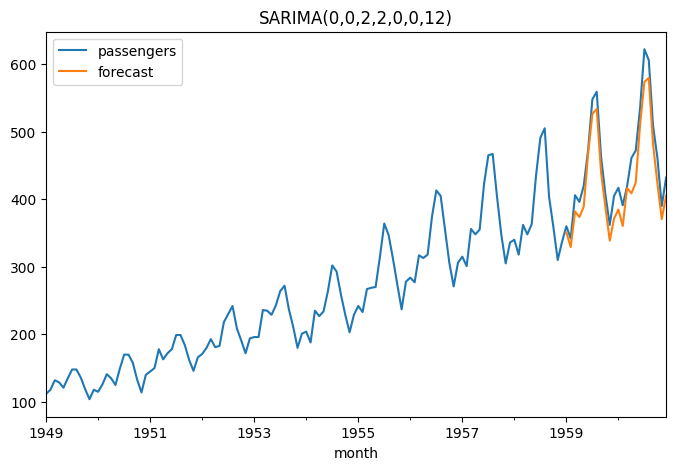

In [30]:
model = sm.tsa.statespace.SARIMAX(data['passengers'],order=(0, 0, 2),seasonal_order=(2,0,0,12)).fit()
data['forecast'] = model.predict(start = 12*10, end = 12*12-1, dynamic = True)
data[['passengers','forecast']].plot(figsize = (8,5),title='SARIMA(0,0,2,2,0,0,12)')

In conclusion, adding seasonality in ARIMA model(SARIMA) makes better result than ARIMA. SARIMA considers the seasonality of data, so it can capture the underlying patterns of data at specific time intervals. This can make more accuarcy in forecasting and improve the performace.

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

In [38]:
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/TAF_Proj.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/TAF_Proj.ipynb to PDF
[NbConvertApp] Support files will be in TAF_Proj_files/
[NbConvertApp] Making directory ./TAF_Proj_files
[NbConvertApp] Making directory ./TAF_Proj_files
[NbConvertApp] Making directory ./TAF_Proj_files
[NbConvertApp] Making directory ./TAF_Proj_files
[NbConvertApp] Making directory ./TAF_Proj_files
[NbConvertApp] Making directory ./TAF_Proj_files
[NbConvertApp] Writing 95508 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 409250 bytes to /content/drive/MyDrive/Colab Notebooks/TAF_Proj.pdf
